# BM-GHSL Surface Match - Paper

In [1]:
import pandas as pd
import pycountry_convert as pc

from conflict_monitoring_ntl.viz import plot_scatter

In [2]:
def country_to_continent(country_name):
    try:
        country_code = pc.country_name_to_country_alpha2(country_name)
        continent_code = pc.country_alpha2_to_continent_code(country_code)
        continent_name = pc.convert_continent_code_to_continent_name(continent_code)
        return continent_name
    except KeyError:
        pass


def merge_datasets(df: pd.DataFrame) -> pd.DataFrame:
    df["f1"]  = 2 * df.TP / (2 * df.TP + df.FP + df.FN)
    df["precision"] = df.TP / (df.TP + df.FP)
    df["recall"] = df.TP / (df.TP + df.FN)

    df["continent"] = df["country"].apply(country_to_continent)
    df = df[(~df.continent.isna()) & (df.continent.isin(["Europe", "Africa"]))]

    hdi_df = pd.read_csv("data/human_development_index.csv")[["iso3", "hdi_2020"]]
    df = pd.merge(left=df, right=hdi_df, how="left", left_on="gid", right_on="iso3")
    df = df[~df.hdi_2020.isna()].rename(columns={"hdi_2020": "hdi"}).drop(columns="iso3")

    urbpop_df = pd.read_csv("data/urban_population.csv")
    urbpop_df = urbpop_df[urbpop_df["Indicator Code"] == "SP.URB.TOTL.IN.ZS"]
    urbpop_df = urbpop_df[["Country Code", "2020"]].rename(columns={"2020": "urban_population"})
    df = pd.merge(df, urbpop_df, how="left", left_on="gid", right_on="Country Code")
    df = df.drop(columns="Country Code")

    min_size, max_size = 10, 40
    pixel_min = df['pixel_count'].min()
    pixel_max = df['pixel_count'].max()
    df['size'] = ((df['pixel_count'] - pixel_min) / (pixel_max - pixel_min)) * (max_size - min_size) + min_size

    return df

In [3]:
countries_to_plot = [
    "South Sudan",
    "Central African Republic",
    "Djibouti",
    "Sudan",
    "Côte d'Ivoire",
    "Libya",
    "Egypt",
    "Malta",
    "Belarus",
    "Algeria",
    "Iceland",
    "Belgium",
    "San Marino",
    "Nigeria",
    "Angola",
    "Sweden",
    "Germany",
    "Italy",
    "Spain",
    "Ukraine",
    "Mali",
    "Niger",
    "Uganda",
    "Zimbabwe",
    "Lithuania",
    "Latvia",
    "Estonia",
    "France",
    "Ghana",
    "Sao Tome and Principe",
    "Morocco",
    "Gabon",
    "Portugal",
    "Romania",
    "Albania"
]

## 1% Threshold

### F1

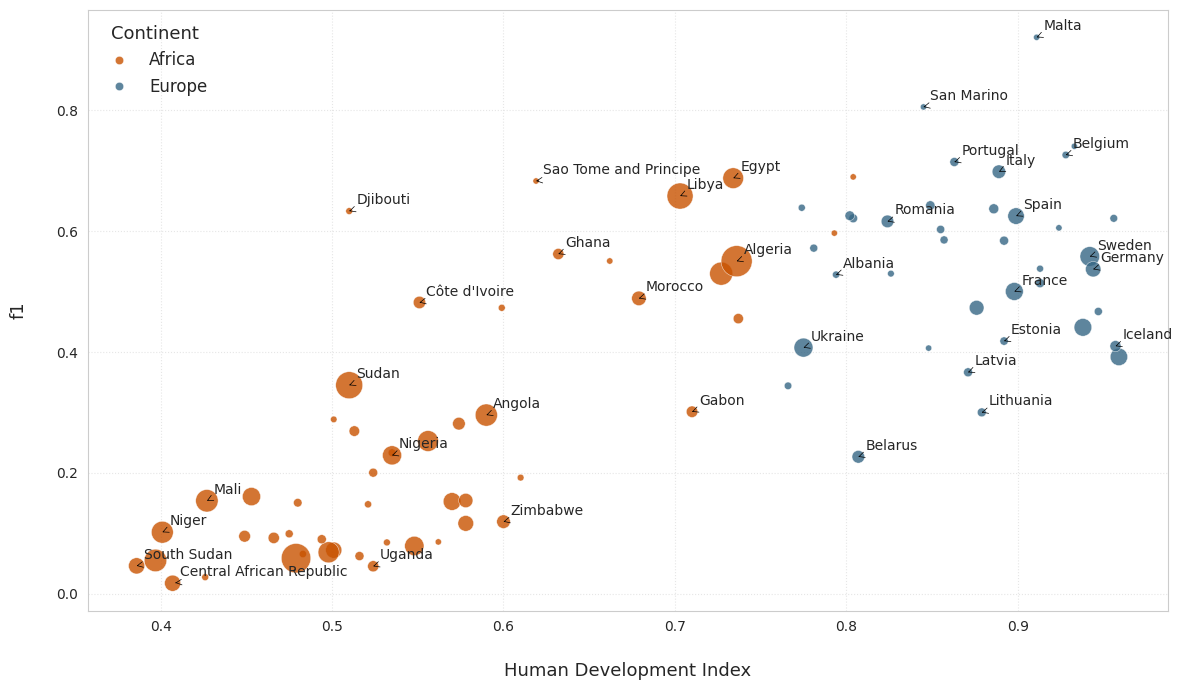

In [4]:
df = pd.read_parquet("results/global_1_percent_thresh")
df = merge_datasets(df)
plot_scatter(df, countries_to_plot)

In [5]:
countries_to_plot = [
    "South Sudan",
    "Central African Republic",
    "Sudan",
    "Côte d'Ivoire",
    "Libya",
    "Egypt",
    "Malta",
    "Belarus",
    "Algeria",
    "Iceland",
    "Belgium",
    "Nigeria",
    "Angola",
    "Sweden",
    "Germany",
    "Italy",
    "Spain",
    "Ukraine",
    "Mali",
    "Niger",
    "Zimbabwe",
    "Latvia",
    "France",
    "Ghana",
    "Morocco",
    "Gabon",
    "Romania",
    "Finland"
]

### Precision

As shown below, the precision - the proportion of correct predictions among all positive predictions - is roughly the same for both Africa and Europe.

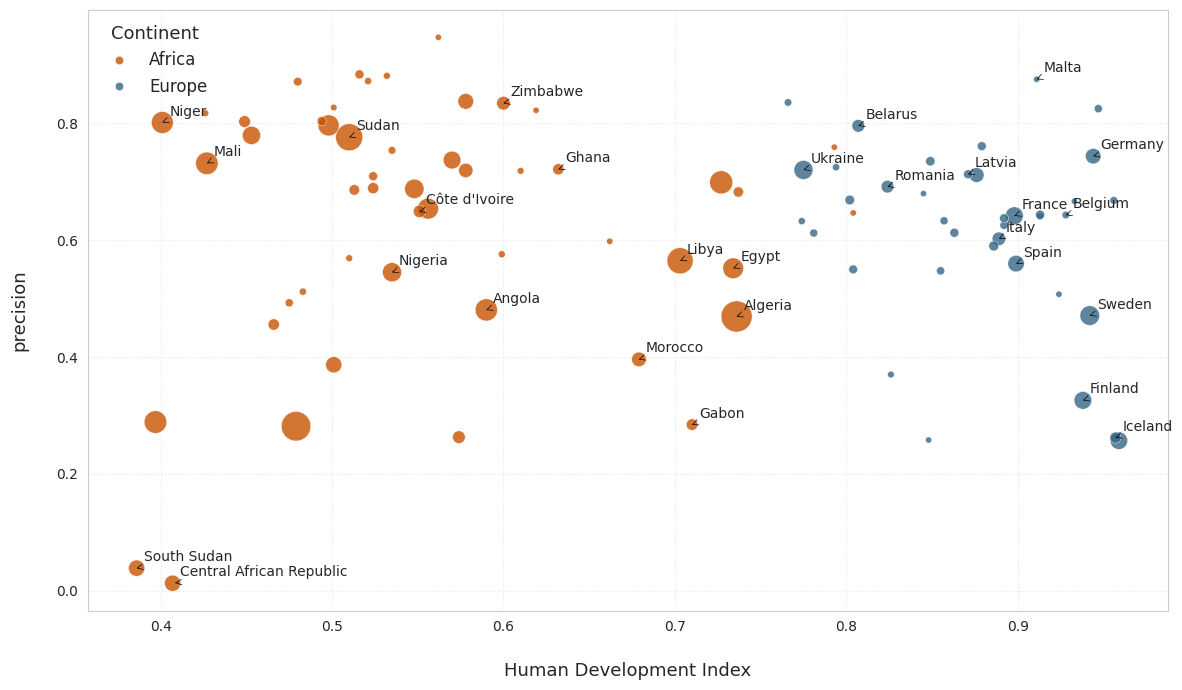

In [6]:
plot_scatter(df, y="precision", ylabel="precision", countries_to_plot=countries_to_plot)

### Recall

The difference between Africa and Europe is primarily due to recall: among all positive labels, the proportion of predicted positives is noticeably lower for Africa.

In [7]:
countries_to_plot = [
    "South Sudan",
    "Central African Republic",
    "Djibouti",
    "Sudan",
    "Côte d'Ivoire",
    "Libya",
    "Egypt",
    "Malta",
    "Belarus",
    "Algeria",
    "Iceland",
    "Belgium",
    "San Marino",
    "Nigeria",
    "Angola",
    "Sweden",
    "Germany",
    "Italy",
    "Spain",
    "Ukraine",
    "Mali",
    "Uganda",
    "Zimbabwe",
    "Lithuania",
    "Latvia",
    "Estonia",
    "France",
    "Ghana",
    "Sao Tome and Principe",
    "Morocco",
    "Gabon",
    "Portugal",
    "Romania",
    "Albania"
]

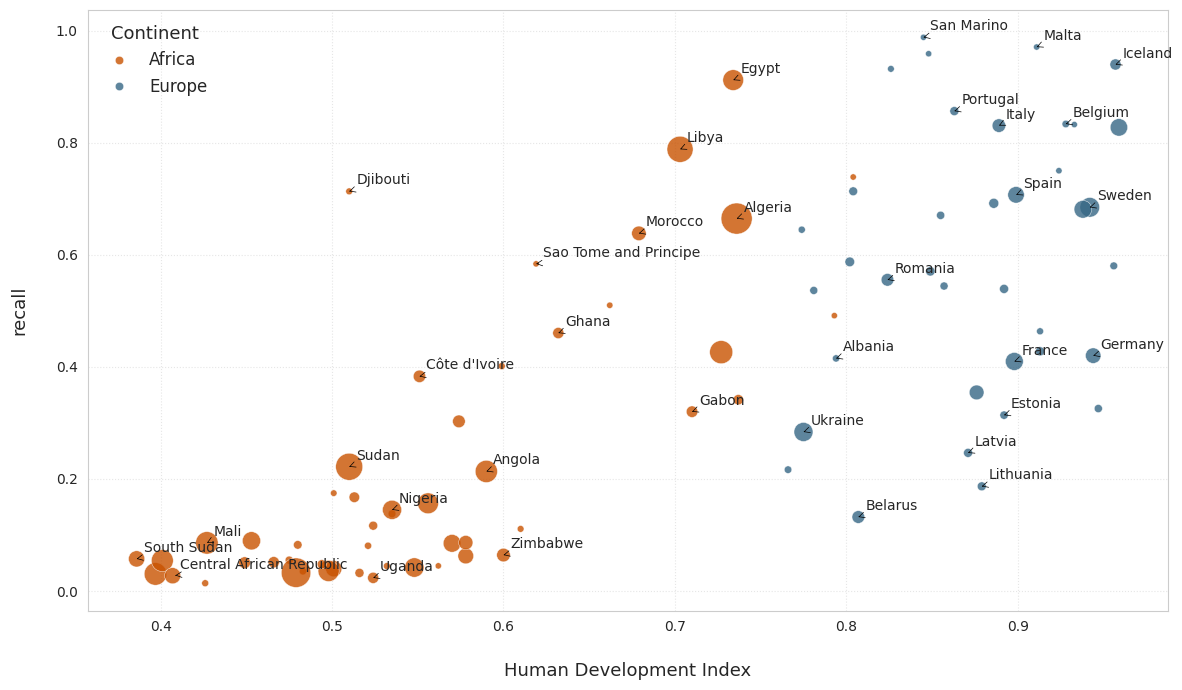

In [8]:
plot_scatter(df, y="recall", ylabel="recall", countries_to_plot=countries_to_plot)

## 20% Threshold

### F1

In [9]:
countries_to_plot = [
    "South Sudan",
    "Central African Republic",
    "Djibouti",
    "Sudan",
    "Côte d'Ivoire",
    "Libya",
    "Egypt",
    "Malta",
    "Belarus",
    "Algeria",
    "Iceland",
    "Nigeria",
    "Angola",
    "Sweden",
    "Germany",
    "Spain",
    "Ukraine",
    "Mali",
    "Niger",
    "Uganda",
    "Kenya",
    "Zimbabwe",
    "Lithuania",
    "France",
    "Ghana",
    "Sao Tome and Principe",
    "Morocco",
    "Gabon",
    "Portugal",
    "Romania",
    "Albania"
    "Gambia",
    "Togo",
    "Liberia",
    "Burkina Faso",
    "Benin",
    "Cameroon",
    "Chad",
    "South Africa"
]

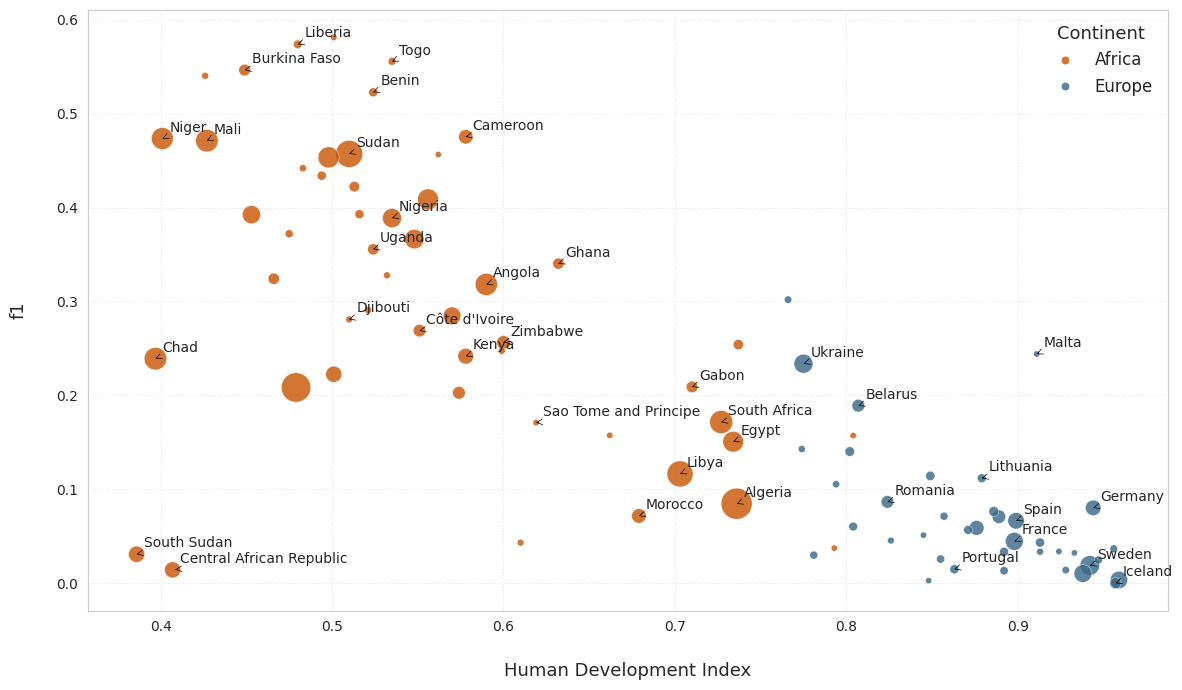

In [10]:
df = pd.read_parquet("results/global_20_percent_thresh")
df = merge_datasets(df)
plot_scatter(df, countries_to_plot, legend_loc="upper right")

### Precision

Precision follows roughly the same pattern as the F1 score.

In [11]:
countries_to_plot = [
    "South Sudan",
    "Central African Republic",
    "Djibouti",
    "Sudan",
    "Côte d'Ivoire",
    "Libya",
    "Egypt",
    "Malta",
    "Belarus",
    "Algeria",
    "Iceland",
    "Nigeria",
    "Angola",
    "Germany",
    "Ukraine",
    "Mali",
    "Niger",
    "Uganda",
    "Kenya",
    "Zimbabwe",
    "Lithuania",
    "France",
    "Ghana",
    "Sao Tome and Principe",
    "Morocco",
    "Gabon",
    "Portugal",
    "Romania",
    "Albania"
    "Gambia",
    "Togo",
    "Liberia",
    "Burkina Faso",
    "Cameroon",
    "Chad",
    "South Africa",
    "Comoros"
]

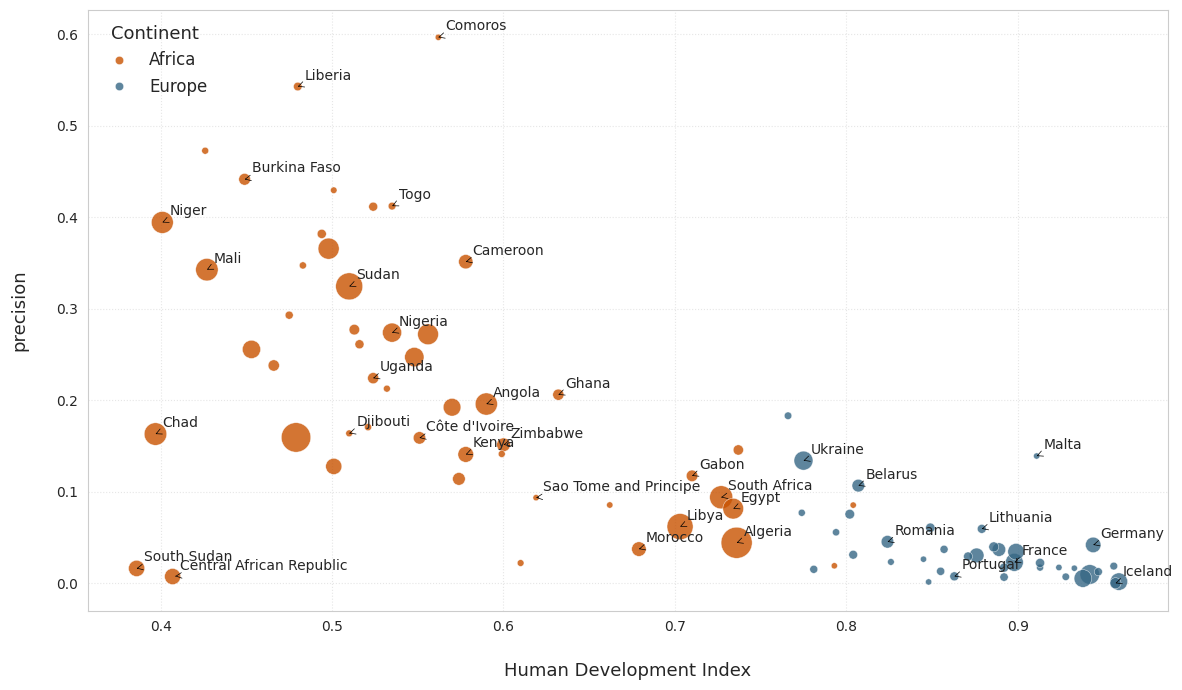

In [12]:
plot_scatter(df, y="precision", ylabel="precision", countries_to_plot=countries_to_plot)

### Recall

With a 20% threshold for GHSL Surface, we are able to identify nearly all positive cases in Europe and a substantial proportion in Africa as well.

In [13]:
countries_to_plot = [
    "South Sudan",
    "Central African Republic",
    "Djibouti",
    "Sudan",
    "Côte d'Ivoire",
    "Libya",
    "Belarus",
    "Iceland",
    "Nigeria",
    "Germany",
    "Ukraine",
    "Mali",
    "Niger",
    "Kenya",
    "Zimbabwe",
    "France",
    "Ghana",
    "Sao Tome and Principe",
    "Morocco",
    "Gabon",
    "Portugal",
    "Romania",
    "Albania"
    "Gambia",
    "Togo",
    "Liberia",
    "Burkina Faso",
    "Benin",
    "Cameroon",
    "Chad",
    "Mozambique",
    "Zambia",
    "Comoros",
    "Eritrea",
    "Denmark"
]

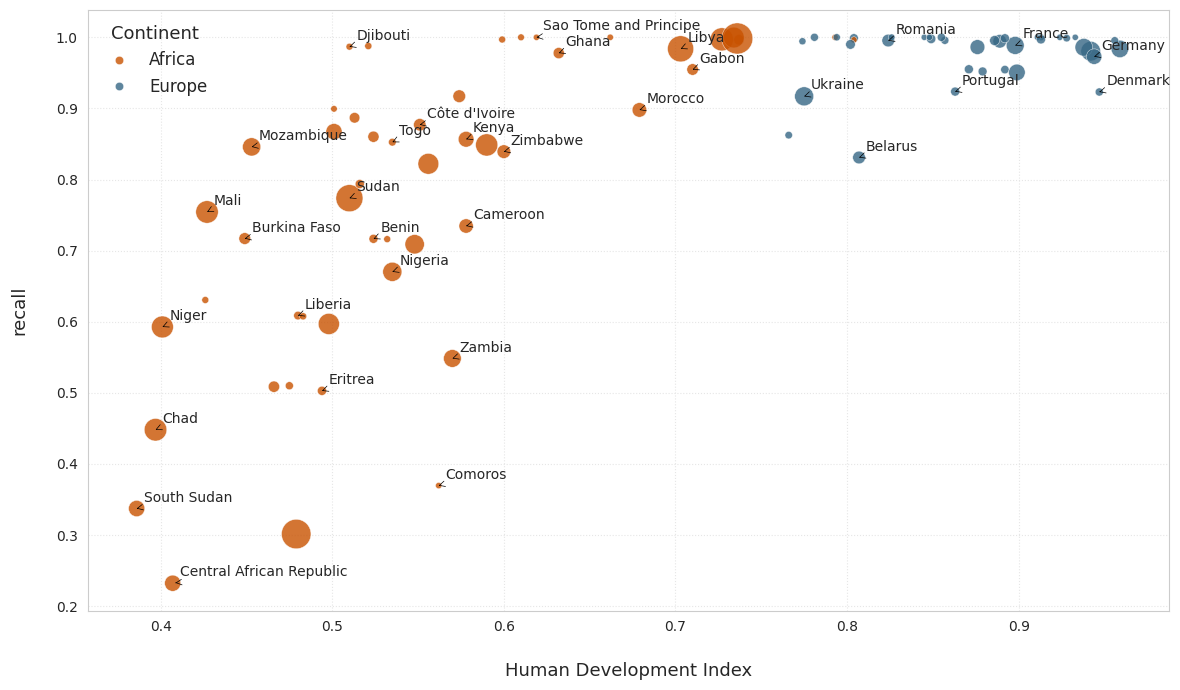

In [14]:
plot_scatter(
    df,
    y="recall",
    ylabel="recall",
    countries_to_plot=countries_to_plot,
)